<a href="https://colab.research.google.com/github/ka-means/adaptive-autonomy-lab/blob/main/01_information_disagreement_autonomous_teams_git_ready.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Notebook 01 Information disagreement in autonomous teams

## Research question

**Under what conditions do information age, confidence miscalibration, and correlated errors make agreement between autonomous agents worse rather than better for collective decision-making?**

This notebook builds a minimal, reproducible model of three autonomous agents that observe the same dynamic environment with different information delays, noisy measurements, and potentially correlated errors.

The model intentionally excludes reinforcement learning in order to isolate information-quality effects before introducing adaptive policies.

### Working hypotheses

- **H1 — Information age matters:** stale observations can degrade team decisions even when sensor noise is unchanged.
- **H2 — Confidence is not reliability:** confidence-weighted fusion can fail when an agent is overconfident.
- **H3 — Correlated errors matter:** majority agreement is less informative when agents fail for the same underlying reason.
- **H4 — High agreement can be wrong:** a team can reach unanimous agreement and still make the wrong decision.

### Minimal model

The true state evolves as:

\[
x_{t+1} = \phi x_t + w_t
\]

Agent \(i\) observes:

\[
y_{i,t} = x_{t-d_i} + \sigma\left(\sqrt{\rho}z_t + \sqrt{1-\rho}z_{i,t}\right)
\]

where:

- \(d_i\): information age / delay,
- \(\sigma\): observation noise,
- \(\rho\): common-mode error correlation,
- \(z_t\): shared noise,
- \(z_{i,t}\): agent-specific noise.

The team must choose between two actions using a decision threshold:

\[
a_t^* = \mathbb{1}[x_t > \theta]
\]

The notebook compares several fusion strategies and measures both decision accuracy and **false consensus**.


## Literature context

The notebook is a controlled reconstruction and synthesis of mechanisms established in several research traditions:

- **Information freshness / Age of Information:** Yates et al. (2021), *Age of Information: An Introduction and Survey*, IEEE JSAC, 39(5), 1183–1210. DOI: `10.1109/JSAC.2021.3065072`.
- **Distributed fusion and consensus:** Olfati-Saber & Shamma (2005), *Consensus Filters for Sensor Networks and Distributed Sensor Fusion*. DOI: `10.1109/CDC.2005.1583238`.
- **Fusion under unknown error correlation:** Julier & Uhlmann (1997), *A Non-divergent Estimation Algorithm in the Presence of Unknown Correlations*. DOI: `10.1109/ACC.1997.609105`.
- **Confidence calibration:** Guo et al. (2017), *On Calibration of Modern Neural Networks*, ICML / PMLR 70.
- **Low disagreement under changing conditions:** Mesto & Cruz (2026), *The Consensus Paradox: When Low Disagreement Leads to Catastrophic Failure in Multi-teacher Reinforcement Learning*. DOI: `10.1007/978-981-95-4972-6_33`.

The experiments below do not claim these mechanisms as novel. They place staleness, common-mode dependence, and confidence miscalibration in one minimal autonomous-team model so their interaction can be inspected under controlled conditions.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", 50)



## 1. Experimental configuration

The default scenario contains three agents. Agent A receives fresh information while Agents B and C can be made increasingly stale. This is deliberate: it creates conditions in which a numerical majority can share old information while a minority agent has a fresher view of the world.


In [2]:

@dataclass(frozen=True)
class ExperimentConfig:
    T: int = 600
    phi: float = 0.96
    process_noise: float = 0.22
    obs_noise: float = 0.30
    rho: float = 0.0
    delays: tuple = (0, 3, 3)
    calibration_factors: tuple = (1.0, 1.0, 1.0)
    threshold: float = 0.0
    regime_change: bool = True
    regime_change_t: int = 300
    fast_phi: float = 0.72
    seed: int = 7



## 2. Environment and local beliefs

Each agent receives a delayed, noisy observation. For now, agents **naively treat the most recent observation they possess as a belief about the current state**. That simplification is intentional: it isolates the cost of stale information before adding prediction or filtering.

Reported uncertainty is allowed to differ from actual uncertainty through a calibration factor:

\[
\hat{\sigma}_i = k_i \sigma
\]

- \(k_i = 1\): calibrated,
- \(k_i < 1\): overconfident,
- \(k_i > 1\): underconfident.


In [3]:

def simulate_environment(cfg: ExperimentConfig):
    rng = np.random.default_rng(cfg.seed)
    x = np.zeros(cfg.T)

    for t in range(1, cfg.T):
        phi_t = cfg.phi
        if cfg.regime_change and t >= cfg.regime_change_t:
            phi_t = cfg.fast_phi
        x[t] = phi_t * x[t-1] + rng.normal(0, cfg.process_noise)

    return x


def simulate_agents(cfg: ExperimentConfig, x):
    rng = np.random.default_rng(cfg.seed + 1)
    n_agents = len(cfg.delays)

    common = rng.normal(0, 1, size=cfg.T)
    individual = rng.normal(0, 1, size=(cfg.T, n_agents))

    observations = np.full((cfg.T, n_agents), np.nan)
    ages = np.zeros((cfg.T, n_agents), dtype=int)
    reported_sigma = np.zeros((cfg.T, n_agents))

    for i, delay in enumerate(cfg.delays):
        for t in range(cfg.T):
            source_t = max(0, t - delay)
            shared_noise = np.sqrt(max(cfg.rho, 0.0)) * common[t]
            private_noise = np.sqrt(max(1.0 - cfg.rho, 0.0)) * individual[t, i]
            noise = cfg.obs_noise * (shared_noise + private_noise)

            observations[t, i] = x[source_t] + noise
            ages[t, i] = t - source_t
            reported_sigma[t, i] = cfg.obs_noise * cfg.calibration_factors[i]

    return observations, ages, reported_sigma



## 3. Fusion strategies

We compare simple mechanisms before introducing learned source selection.

1. **Mean:** equal weight for every source.
2. **Freshest:** trust only the source with the smallest Age of Information.
3. **Confidence-weighted:** weight observations by inverse reported variance.
4. **Reliability-weighted:** estimate source reliability from historical squared error.
5. **Majority:** each agent converts its belief into a binary action and the team selects the majority action.

The reliability-weighted method is intentionally optimistic because it estimates reliability using access to the true state during a calibration period. We use it as an interpretable baseline, not as a deployable algorithm.


In [4]:

def fuse_mean(obs):
    return np.mean(obs, axis=1)


def fuse_freshest(obs, ages):
    fused = np.zeros(obs.shape[0])
    for t in range(obs.shape[0]):
        idx = np.argmin(ages[t])
        fused[t] = obs[t, idx]
    return fused


def fuse_confidence_weighted(obs, reported_sigma):
    precision = 1.0 / np.maximum(reported_sigma, 1e-8) ** 2
    weights = precision / precision.sum(axis=1, keepdims=True)
    return np.sum(weights * obs, axis=1)


def estimate_reliability_weights(obs, x, calibration_end):
    errors = obs[:calibration_end] - x[:calibration_end, None]
    mse = np.mean(errors ** 2, axis=0)
    inv_mse = 1.0 / np.maximum(mse, 1e-8)
    return inv_mse / inv_mse.sum()


def fuse_reliability_weighted(obs, x, calibration_end=150):
    weights = estimate_reliability_weights(obs, x, calibration_end)
    return np.sum(obs * weights[None, :], axis=1), weights


def majority_action(obs, threshold=0.0):
    local_actions = (obs > threshold).astype(int)
    votes = np.sum(local_actions, axis=1)
    majority = (votes >= (obs.shape[1] // 2 + 1)).astype(int)
    return majority, local_actions


## 4. Metrics

We distinguish estimation quality from decision quality.

### RMSE

\[
RMSE = \sqrt{\frac{1}{T}\sum_t(\hat{x}_t-x_t)^2}
\]

### Decision accuracy

\[
P(\hat{a}_t = a_t^*)
\]

### Mean disagreement

We use the average cross-agent standard deviation of local beliefs.

### False consensus rate

For this notebook, false consensus is operationally defined as:

> **all agents take the same binary action and that unanimous action is wrong.**

\[
FCR = P(\text{unanimous agreement} \land \text{wrong})
\]

This is a notebook-specific operational metric, not a claim of a new field-wide definition.


In [5]:

def evaluate_fused_estimate(fused, x, threshold=0.0):
    true_action = (x > threshold).astype(int)
    pred_action = (fused > threshold).astype(int)

    rmse = float(np.sqrt(np.mean((fused - x) ** 2)))
    decision_accuracy = float(np.mean(pred_action == true_action))

    return {
        "rmse": rmse,
        "decision_accuracy": decision_accuracy
    }


def disagreement_metric(obs):
    return float(np.mean(np.std(obs, axis=1)))


def false_consensus_rate(local_actions, x, threshold=0.0):
    true_action = (x > threshold).astype(int)
    unanimous = np.all(local_actions == local_actions[:, [0]], axis=1)
    unanimous_action = local_actions[:, 0]
    wrong = unanimous_action != true_action

    if len(unanimous) == 0:
        return np.nan

    return float(np.mean(unanimous & wrong))


def run_once(cfg: ExperimentConfig):
    x = simulate_environment(cfg)
    obs, ages, reported_sigma = simulate_agents(cfg, x)

    mean_est = fuse_mean(obs)
    fresh_est = fuse_freshest(obs, ages)
    conf_est = fuse_confidence_weighted(obs, reported_sigma)
    rel_est, rel_weights = fuse_reliability_weighted(
        obs, x, calibration_end=max(30, cfg.T // 4)
    )
    majority, local_actions = majority_action(obs, cfg.threshold)

    true_action = (x > cfg.threshold).astype(int)

    rows = []

    for name, est in [
        ("mean", mean_est),
        ("freshest", fresh_est),
        ("confidence_weighted", conf_est),
        ("reliability_weighted", rel_est),
    ]:
        metrics = evaluate_fused_estimate(est, x, cfg.threshold)
        rows.append({
            "strategy": name,
            **metrics,
            "mean_disagreement": disagreement_metric(obs),
            "false_consensus_rate": false_consensus_rate(
                local_actions, x, cfg.threshold
            )
        })

    rows.append({
        "strategy": "majority_vote",
        "rmse": np.nan,
        "decision_accuracy": float(np.mean(majority == true_action)),
        "mean_disagreement": disagreement_metric(obs),
        "false_consensus_rate": false_consensus_rate(
            local_actions, x, cfg.threshold
        )
    })

    return pd.DataFrame(rows), {
        "x": x,
        "obs": obs,
        "ages": ages,
        "reported_sigma": reported_sigma,
        "reliability_weights": rel_weights,
        "majority": majority,
        "local_actions": local_actions,
        "mean_est": mean_est,
        "fresh_est": fresh_est,
        "conf_est": conf_est,
        "rel_est": rel_est
    }



## 5. Baseline experiment

Run the default configuration first. The environment changes dynamics halfway through the episode, while two of the three agents operate with stale information.


In [6]:

baseline_cfg = ExperimentConfig()
baseline_results, baseline = run_once(baseline_cfg)

baseline_results


,strategy,rmse,decision_accuracy,mean_disagreement,false_consensus_rate
0,mean,0.277439,0.843333,0.264121,0.038333
1,freshest,0.301295,0.848333,0.264121,0.038333
2,confidence_weighted,0.277439,0.843333,0.264121,0.038333
3,reliability_weighted,0.239924,0.848333,0.264121,0.038333
4,majority_vote,NaN,0.811667,0.264121,0.038333


In [7]:

print("Reliability weights learned during calibration period:")
print(dict(zip(["Agent A", "Agent B", "Agent C"], baseline["reliability_weights"].round(3))))


Reliability weights learned during calibration period:
{'Agent A': np.float64(0.512), 'Agent B': np.float64(0.253), 'Agent C': np.float64(0.235)}



### Visual inspection of the true state and local beliefs

The next plot is not a performance result; it is a diagnostic view of how different local beliefs can become around a changing state.


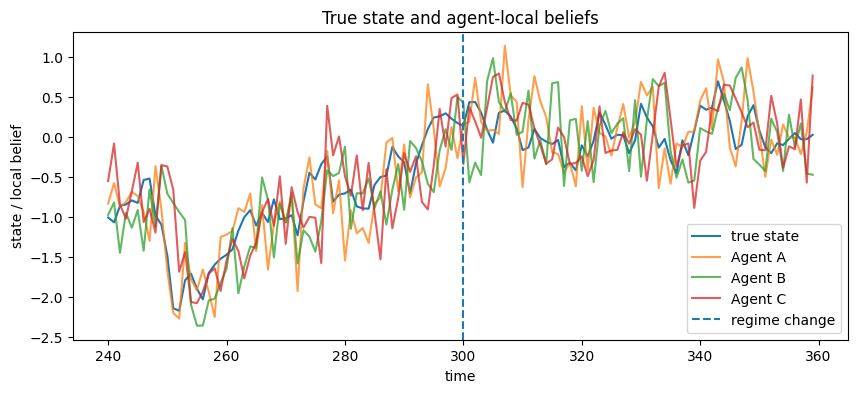

In [8]:

window = slice(240, 360)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(baseline_cfg.T)[window], baseline["x"][window], label="true state")
for i in range(baseline["obs"].shape[1]):
    plt.plot(
        np.arange(baseline_cfg.T)[window],
        baseline["obs"][window, i],
        alpha=0.75,
        label=f"Agent {chr(65+i)}"
    )
plt.axvline(baseline_cfg.regime_change_t, linestyle="--", label="regime change")
plt.xlabel("time")
plt.ylabel("state / local belief")
plt.title("True state and agent-local beliefs")
plt.legend()
plt.show()



## 6. Experiment A — Age of Information

We progressively increase the delay of Agents B and C while Agent A remains fresh.

This directly tests H1.

To reduce Monte Carlo noise, each configuration is repeated across several seeds.


In [9]:

def sweep_aoi(delays=(0, 1, 3, 5, 8, 12), runs=12):
    records = []

    for d in delays:
        for run in range(runs):
            cfg = ExperimentConfig(
                delays=(0, d, d),
                rho=0.0,
                obs_noise=0.30,
                calibration_factors=(1.0, 1.0, 1.0),
                seed=1000 + run
            )
            result, _ = run_once(cfg)
            result["stale_delay"] = d
            result["run"] = run
            records.append(result)

    return pd.concat(records, ignore_index=True)


aoi_df = sweep_aoi()

aoi_summary = (
    aoi_df.groupby(["stale_delay", "strategy"], as_index=False)
    .agg(
        decision_accuracy=("decision_accuracy", "mean"),
        rmse=("rmse", "mean"),
        false_consensus_rate=("false_consensus_rate", "mean")
    )
)

aoi_summary.head(10)


,stale_delay,strategy,decision_accuracy,rmse,false_consensus_rate
0,0,confidence_weighted,0.886250,0.171855,0.021944
1,0,freshest,0.815694,0.299337,0.021944
2,0,majority_vote,0.866944,NaN,0.021944
3,0,mean,0.886250,0.171855,0.021944
4,0,reliability_weighted,0.885694,0.172292,0.021944
5,1,confidence_weighted,0.840833,0.229475,0.036528
6,1,freshest,0.815694,0.299337,0.036528
7,1,majority_vote,0.817500,NaN,0.036528
8,1,mean,0.840833,0.229475,0.036528
9,1,reliability_weighted,0.847917,0.219633,0.036528


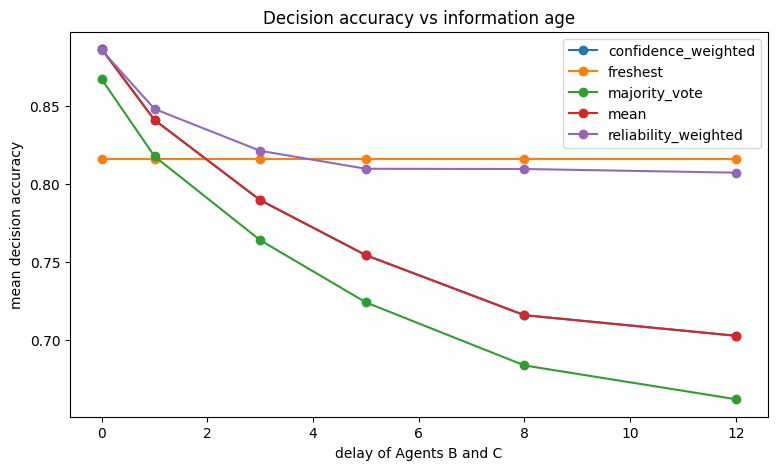

In [10]:

plt.figure(figsize=(9, 5))

for strategy in aoi_summary["strategy"].unique():
    subset = aoi_summary[aoi_summary["strategy"] == strategy]
    plt.plot(
        subset["stale_delay"],
        subset["decision_accuracy"],
        marker="o",
        label=strategy
    )

plt.xlabel("delay of Agents B and C")
plt.ylabel("mean decision accuracy")
plt.title("Decision accuracy vs information age")
plt.legend()
plt.show()


## 7. Experiment B — Correlated errors and false consensus

Now the information is equally fresh, but agent errors increasingly share a common component.

When \(\rho \to 1\), multiple agents can agree because they are being pushed in the same direction by a shared error component.

This tests H3 and H4.


In [11]:

def sweep_correlation(rhos=(0.0, 0.2, 0.4, 0.6, 0.8, 0.95), runs=20):
    records = []

    for rho in rhos:
        for run in range(runs):
            cfg = ExperimentConfig(
                delays=(0, 0, 0),
                rho=rho,
                obs_noise=0.45,
                calibration_factors=(1.0, 1.0, 1.0),
                seed=2000 + run
            )
            result, _ = run_once(cfg)
            result["rho"] = rho
            result["run"] = run
            records.append(result)

    return pd.concat(records, ignore_index=True)


corr_df = sweep_correlation()

corr_summary = (
    corr_df.groupby(["rho", "strategy"], as_index=False)
    .agg(
        decision_accuracy=("decision_accuracy", "mean"),
        false_consensus_rate=("false_consensus_rate", "mean"),
        mean_disagreement=("mean_disagreement", "mean")
    )
)

corr_summary.head(10)


,rho,strategy,decision_accuracy,false_consensus_rate,mean_disagreement
0,0.0,confidence_weighted,0.836917,0.030583,0.324905
1,0.0,freshest,0.757917,0.030583,0.324905
2,0.0,majority_vote,0.819333,0.030583,0.324905
3,0.0,mean,0.836917,0.030583,0.324905
4,0.0,reliability_weighted,0.838333,0.030583,0.324905
5,0.2,confidence_weighted,0.811417,0.051083,0.290604
6,0.2,freshest,0.752750,0.051083,0.290604
7,0.2,majority_vote,0.798167,0.051083,0.290604
8,0.2,mean,0.811417,0.051083,0.290604
9,0.2,reliability_weighted,0.810083,0.051083,0.290604


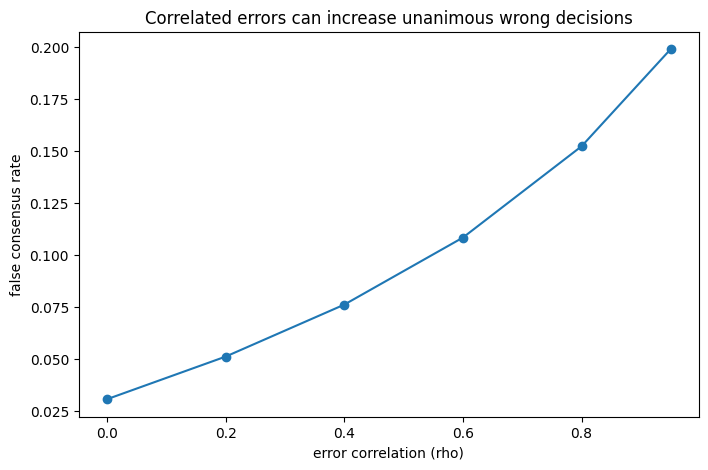

In [12]:

majority_corr = corr_summary[corr_summary["strategy"] == "majority_vote"]

plt.figure(figsize=(8, 5))
plt.plot(
    majority_corr["rho"],
    majority_corr["false_consensus_rate"],
    marker="o"
)
plt.xlabel("error correlation (rho)")
plt.ylabel("false consensus rate")
plt.title("Correlated errors can increase unanimous wrong decisions")
plt.show()



## 8. Experiment C — Confidence miscalibration

Agents B and C will become increasingly overconfident while Agent A remains calibrated.

Because confidence-weighted fusion uses reported uncertainty, this can give stale or noisy sources excessive influence.

This tests H2.


In [13]:

def sweep_miscalibration(
    factors=(1.5, 1.0, 0.8, 0.6, 0.4, 0.25),
    runs=15
):
    records = []

    for k in factors:
        for run in range(runs):
            cfg = ExperimentConfig(
                delays=(0, 4, 4),
                rho=0.35,
                obs_noise=0.35,
                calibration_factors=(1.0, k, k),
                seed=3000 + run
            )
            result, _ = run_once(cfg)
            result["stale_agent_calibration_factor"] = k
            result["run"] = run
            records.append(result)

    return pd.concat(records, ignore_index=True)


cal_df = sweep_miscalibration()

cal_summary = (
    cal_df.groupby(
        ["stale_agent_calibration_factor", "strategy"],
        as_index=False
    )
    .agg(
        decision_accuracy=("decision_accuracy", "mean"),
        false_consensus_rate=("false_consensus_rate", "mean")
    )
)

cal_summary.head(10)


,stale_agent_calibration_factor,strategy,decision_accuracy,false_consensus_rate
0,0.25,confidence_weighted,0.686778,0.077111
1,0.25,freshest,0.804222,0.077111
2,0.25,majority_vote,0.727889,0.077111
3,0.25,mean,0.746667,0.077111
4,0.25,reliability_weighted,0.785000,0.077111
5,0.40,confidence_weighted,0.694778,0.077111
6,0.40,freshest,0.804222,0.077111
7,0.40,majority_vote,0.727889,0.077111
8,0.40,mean,0.746667,0.077111
9,0.40,reliability_weighted,0.785000,0.077111


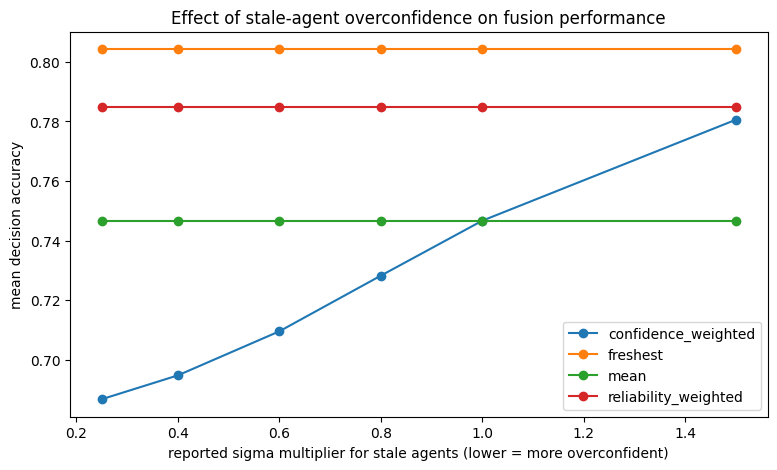

In [14]:

focus = cal_summary[
    cal_summary["strategy"].isin(
        ["confidence_weighted", "freshest", "mean", "reliability_weighted"]
    )
]

plt.figure(figsize=(9, 5))

for strategy in focus["strategy"].unique():
    subset = focus[focus["strategy"] == strategy].sort_values(
        "stale_agent_calibration_factor"
    )
    plt.plot(
        subset["stale_agent_calibration_factor"],
        subset["decision_accuracy"],
        marker="o",
        label=strategy
    )

plt.xlabel("reported sigma multiplier for stale agents (lower = more overconfident)")
plt.ylabel("mean decision accuracy")
plt.title("Effect of stale-agent overconfidence on fusion performance")
plt.legend()
plt.show()



## 9. Joint stress test — age × correlation × miscalibration

The previous experiments varied one mechanism at a time. This final section combines them.

The objective is not to exhaustively optimize the system. It is to identify **regions of failure** worth studying later.

We compare a benign configuration with a stressed configuration:

- **Benign:** fresh, independent, calibrated sources.
- **Stressed:** two stale sources, correlated errors, and overconfidence.


In [15]:

scenarios = {
    "benign": ExperimentConfig(
        delays=(0, 0, 0),
        rho=0.0,
        obs_noise=0.30,
        calibration_factors=(1.0, 1.0, 1.0),
        seed=55
    ),
    "stressed": ExperimentConfig(
        delays=(0, 6, 6),
        rho=0.75,
        obs_noise=0.35,
        calibration_factors=(1.0, 0.40, 0.40),
        seed=55
    ),
}

scenario_results = []

for name, cfg in scenarios.items():
    result, _ = run_once(cfg)
    result["scenario"] = name
    scenario_results.append(result)

scenario_df = pd.concat(scenario_results, ignore_index=True)

scenario_df[
    ["scenario", "strategy", "decision_accuracy", "rmse", "false_consensus_rate"]
].sort_values(["scenario", "decision_accuracy"], ascending=[True, False])


,scenario,strategy,decision_accuracy,rmse,false_consensus_rate
0,benign,mean,0.870000,0.176477,0.021667
2,benign,confidence_weighted,0.870000,0.176477,0.021667
3,benign,reliability_weighted,0.870000,0.176617,0.021667
4,benign,majority_vote,0.851667,NaN,0.021667
1,benign,freshest,0.813333,0.305592,0.021667
6,stressed,freshest,0.775000,0.350879,0.156667
8,stressed,reliability_weighted,0.726667,0.373620,0.156667
5,stressed,mean,0.678333,0.460814,0.156667
9,stressed,majority_vote,0.656667,NaN,0.156667
7,stressed,confidence_weighted,0.625000,0.554160,0.156667


## Interpretation

The experiments support a limited conclusion within this simulation: agreement is not, by itself, a reliable proxy for information quality. Its meaning depends on the freshness of the underlying observations, the dependence structure of source errors, and the calibration of reported uncertainty.

The notebook does not establish that consensus is generally harmful, that freshest-source selection is generally optimal, or that the simulated failure rates transfer to physical multi-robot systems. Its role is to provide a reproducible baseline for studying when distributed agreement can become misleading.
